In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sales = pd.read_csv("sales.csv")
inventory = pd.read_csv("inventory.csv")
products = pd.read_csv("products.csv")
warehouses = pd.read_csv("warehouses.csv")
suppliers = pd.read_csv("suppliers.csv")

In [5]:
sales['order_date'] = pd.to_datetime(sales['order_date'], format='%m/%d/%Y')

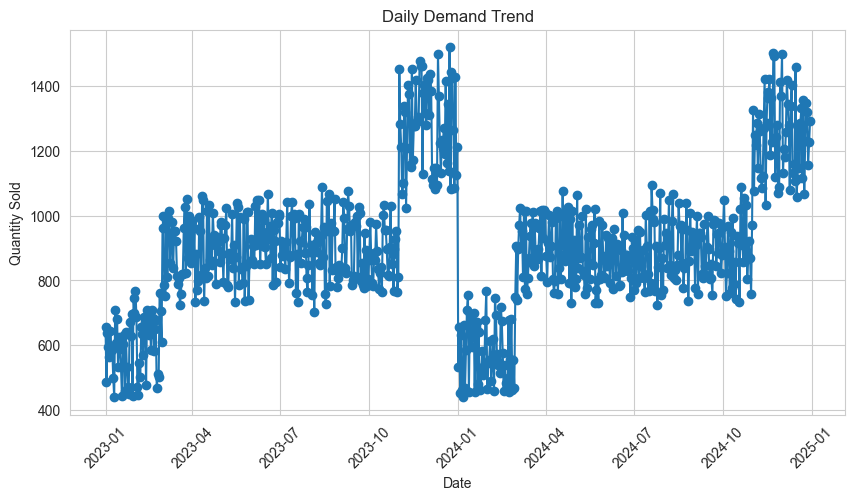

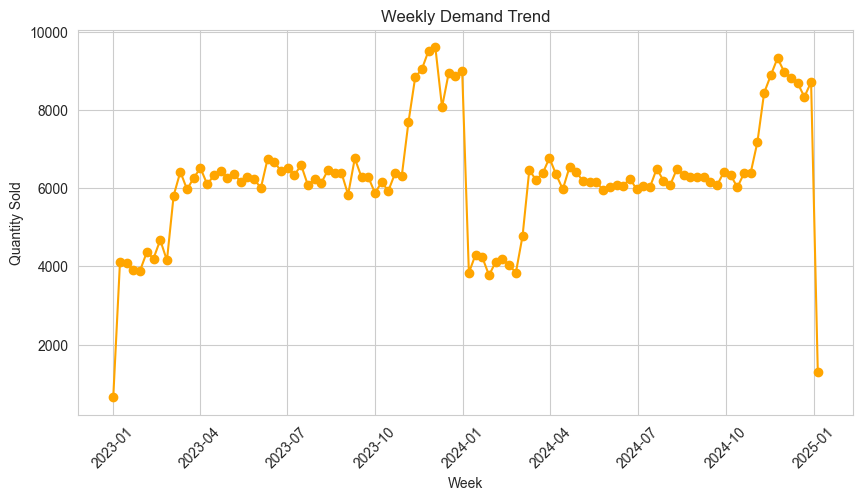

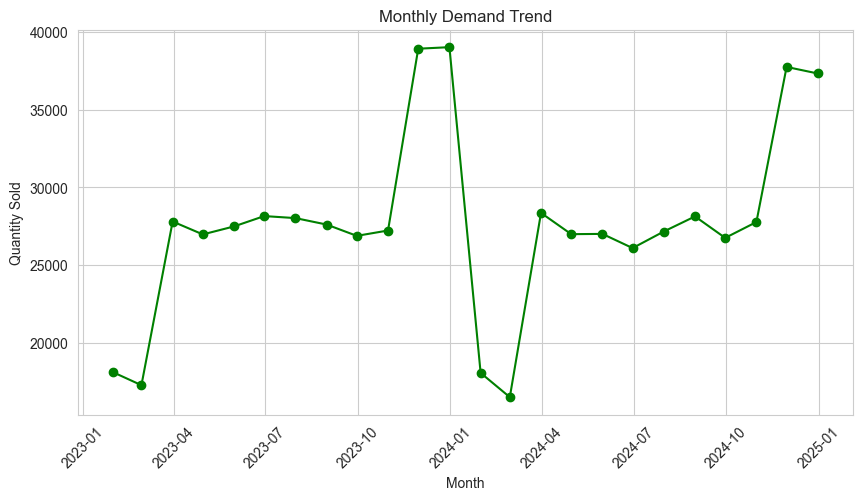

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV Load
sales = pd.read_csv("sales.csv")
sales['order_date'] = pd.to_datetime(sales['order_date'], format='%m/%d/%Y')

# Daily trend
daily = sales.groupby('order_date')['quantity'].sum().reset_index()
plt.plot(daily['order_date'], daily['quantity'], marker='o')
plt.title("Daily Demand Trend")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

# Weekly trend
weekly = sales.set_index('order_date').resample('W')['quantity'].sum().reset_index()
plt.plot(weekly['order_date'], weekly['quantity'], marker='o', color='orange')
plt.title("Weekly Demand Trend")
plt.xlabel("Week")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

# Monthly trend
monthly = sales.set_index('order_date').resample('ME')['quantity'].sum().reset_index()
plt.plot(monthly['order_date'], monthly['quantity'], marker='o', color='green')
plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

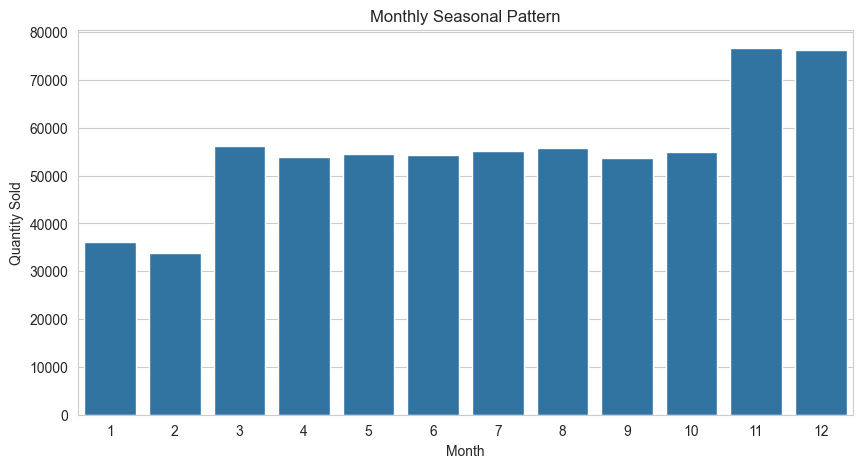

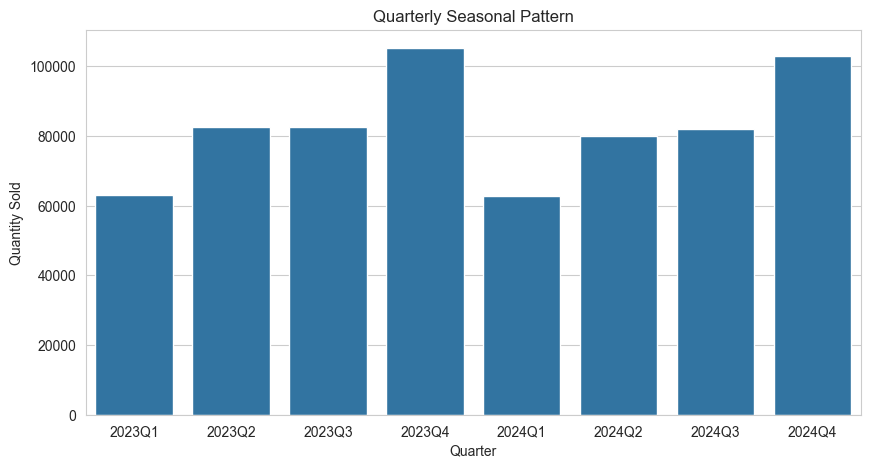

In [10]:
# ------------------------
# Seasonal Pattern Analysis
# ------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sales = pd.read_csv("sales.csv")
sales['order_date'] = pd.to_datetime(sales['order_date'], format='%m/%d/%Y')
sales['month'] = sales['order_date'].dt.month
sales['quarter'] = sales['order_date'].dt.to_period('Q')

# Month-wise
month_sales = sales.groupby('month')['quantity'].sum().reset_index()
sns.barplot(x='month', y='quantity', data=month_sales,)
plt.title("Monthly Seasonal Pattern")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")
plt.show()

# Quarter-wise
quarter_sales = sales.groupby('quarter')['quantity'].sum().reset_index()
sns.barplot(x='quarter', y='quantity', data=quarter_sales,)
plt.title("Quarterly Seasonal Pattern")
plt.xlabel("Quarter")
plt.ylabel("Quantity Sold")
plt.show()

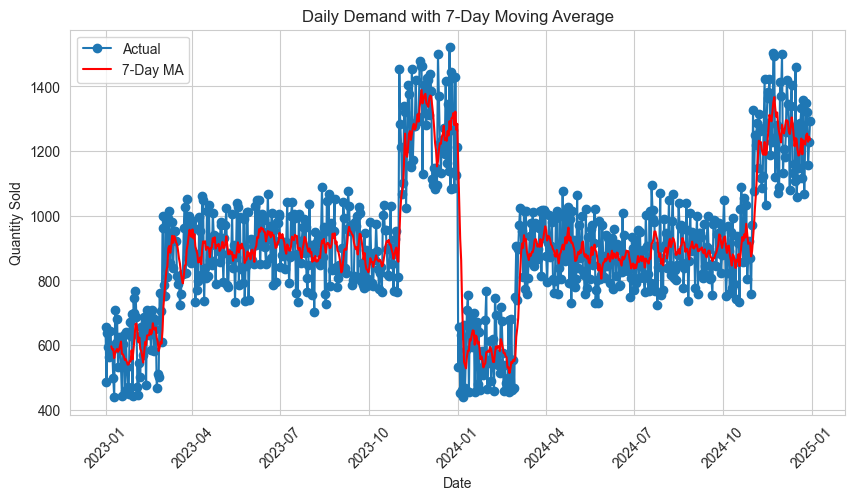

In [11]:
# ------------------------
# Moving Average Forecasting
# ------------------------
import pandas as pd
import matplotlib.pyplot as plt

sales = pd.read_csv("sales.csv")
sales['order_date'] = pd.to_datetime(sales['order_date'], format='%m/%d/%Y')

# Daily sales sum
daily = sales.groupby('order_date')['quantity'].sum().reset_index()

# 7-day moving average
daily['7day_MA'] = daily['quantity'].rolling(window=7).mean()

plt.plot(daily['order_date'], daily['quantity'], label='Actual', marker='o')
plt.plot(daily['order_date'], daily['7day_MA'], label='7-Day MA', color='red')
plt.title("Daily Demand with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.legend()
plt.xticks(rotation=45)
plt.show()